In [13]:
import pandas as pd
import numpy as np

from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, roc_auc_score
from scipy.stats import spearmanr

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    ExtraTreesClassifier,
    ExtraTreesRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    AdaBoostClassifier,
    AdaBoostRegressor
)
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR
from Model_pipeline import TwoStagePipeline


def safe_spearman(y_true, y_pred):
    corr = spearmanr(y_true, y_pred).correlation
    return 0.0 if pd.isna(corr) else corr


def evaluate_model_pair(pipeline, classifier, regressor, model_name):
    clf = clone(classifier)
    reg = clone(regressor)

    clf.fit(pipeline.X_train, pipeline.y_class_train)

    mask_train = pipeline.y_class_train == 1
    if mask_train.sum() == 0:
        raise ValueError("No positive buyers in training set for regressor.")

    reg.fit(
        pipeline.X_train[mask_train],
        np.log1p(pipeline.y_reg_train[mask_train])
    )

    proba_val = clf.predict_proba(pipeline.X_val)[:, 1]
    auc = roc_auc_score(pipeline.y_class_val, proba_val)

    reg_pred_log = reg.predict(pipeline.X_val)
    reg_pred = np.expm1(reg_pred_log)
    reg_pred = np.clip(reg_pred, 0, None)

    pred_expected = proba_val * reg_pred
    pred_expected = np.clip(pred_expected, 0, None)

    mae = mean_absolute_error(pipeline.y_reg_val, pred_expected)
    spearman_corr = safe_spearman(pipeline.y_reg_val, pred_expected)

    return {
        "model_name": model_name,
        "AUC": auc,
        "MAE": mae,
        "Spearman": spearman_corr
    }


mymodel = TwoStagePipeline()
mymodel.load_data()
mymodel.preprocess_dates()
mymodel.prepare_training_data()
mymodel.split_data()       

Features shape: (145739, 73)
Train shape: (116591, 2)
Test shape: (29148, 1)
Training matrix shape: (116591, 72)
Positive buyers ratio: 0.3659
X_train shape: (93272, 72)
X_val shape: (23319, 72)


In [14]:
model_configs = [
    {
        "name": "LogReg + GBR",
        "classifier": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
        "regressor": GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        random_state=42
    )
    },
    {
        "name": "RF + RF",
        "classifier": RandomForestClassifier(
            n_estimators=400,
            max_depth=12,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),
        "regressor": RandomForestRegressor(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        )
    },
    {
        "name": "ExtraTrees + ExtraTrees",
        "classifier": ExtraTreesClassifier(
            n_estimators=400,
            max_depth=12,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),
        "regressor": ExtraTreesRegressor(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        )
    },
    {
        "name": "GBR Classifier + GBR Regressor",
        "classifier": GradientBoostingClassifier(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ),
        "regressor": GradientBoostingRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            random_state=42
        )
    },
    {
        "name": "AdaBoost + AdaBoost",
        "classifier": AdaBoostClassifier(random_state=42),
        "regressor": AdaBoostRegressor(random_state=42)
    },
    {
        "name": "KNN + KNN",
        "classifier": KNeighborsClassifier(n_neighbors=25),
        "regressor": KNeighborsRegressor(n_neighbors=25)
    },
    {
        "name": "SVC + SVR",
        "classifier": SVC(probability=True, class_weight="balanced", random_state=42),
        "regressor": SVR()
    },
    {
        "name": "LogReg + RF",
        "classifier": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
        "regressor": RandomForestRegressor(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        )
    },
    {
        "name": "ExtraTrees + RF",
        "classifier": ExtraTreesClassifier(
            n_estimators=400,
            max_depth=12,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),
        "regressor": RandomForestRegressor(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        )
    }
]

results = []

for config in model_configs:
    print(f"Testing {config['name']}...")
    try:
        result = evaluate_model_pair(
            pipeline=mymodel,
            classifier=config["classifier"],
            regressor=config["regressor"],
            model_name=config["name"]
        )
        results.append(result)
        print(
            f"{result['model_name']} | "
            f"AUC={result['AUC']:.4f} | "
            f"MAE={result['MAE']:.4f} | "
            f"Spearman={result['Spearman']:.4f}"
        )
    except Exception as e:
        print(f"{config['name']} failed: {e}")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="MAE", ascending=True).reset_index(drop=True)

print("\nFinal ranking by MAE:")
print(results_df)

results_df.to_csv("model_comparison.csv", index=False)

Testing LogReg + GBR...


/Users/dorianforton/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogReg + GBR | AUC=0.7072 | MAE=77.1047 | Spearman=0.3771
Testing RF + RF...


KeyboardInterrupt: 

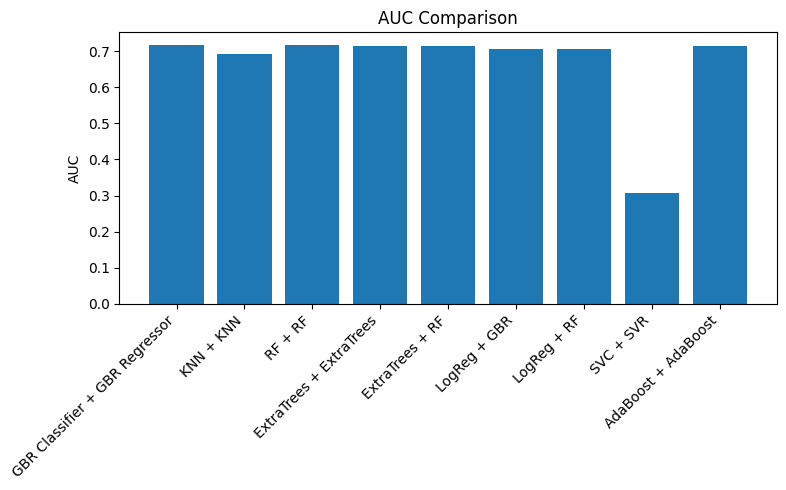

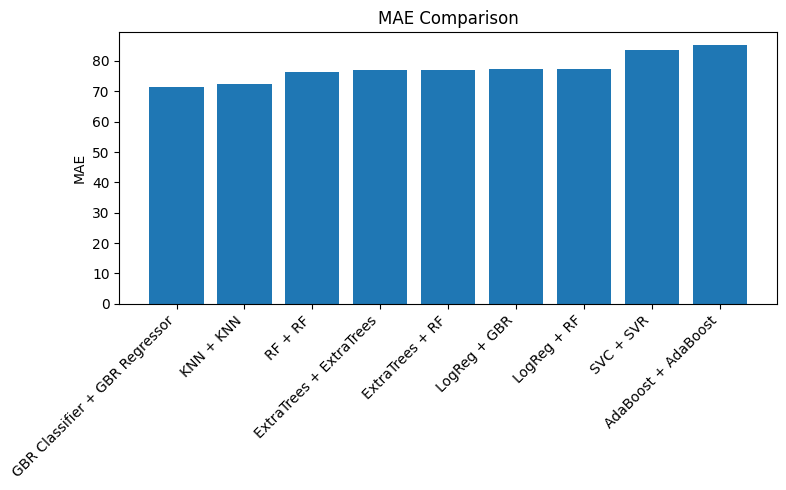

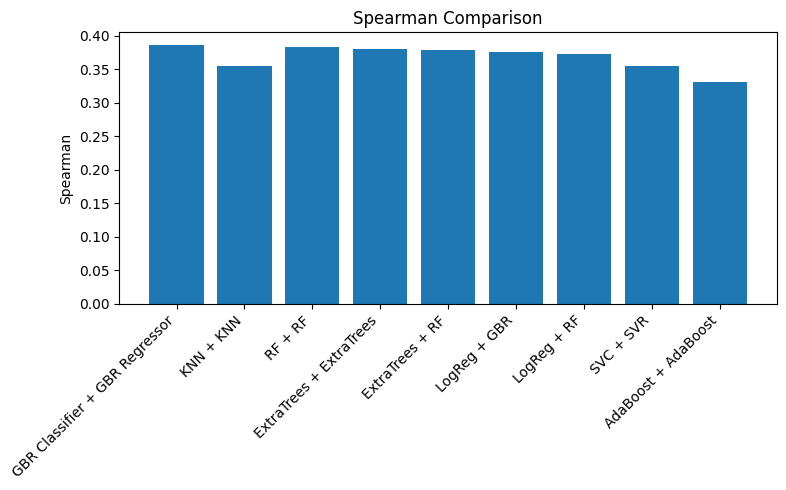

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(results_df["model_name"], results_df["AUC"])
plt.title("AUC Comparison")
plt.ylabel("AUC")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(results_df["model_name"], results_df["MAE"])
plt.title("MAE Comparison")
plt.ylabel("MAE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(results_df["model_name"], results_df["Spearman"])
plt.title("Spearman Comparison")
plt.ylabel("Spearman")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [11]:
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.base import clone

# Define your tuned model
clf = GradientBoostingClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

reg = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

# Clone (good practice)
clf = clone(clf)
reg = clone(reg)

# Train classifier
clf.fit(mymodel.X_train, mymodel.y_class_train)

# Train regressor only on buyers
mask_train = mymodel.y_class_train == 1
reg.fit(
    mymodel.X_train[mask_train],
    np.log1p(mymodel.y_reg_train[mask_train])
)

# Predict
proba_val = clf.predict_proba(mymodel.X_val)[:, 1]
reg_pred = np.expm1(reg.predict(mymodel.X_val))
reg_pred = np.clip(reg_pred, 0, None)

pred_expected = proba_val * reg_pred

# Metrics
auc = roc_auc_score(mymodel.y_class_val, proba_val)
mae = mean_absolute_error(mymodel.y_reg_val, pred_expected)
spearman_corr = safe_spearman(mymodel.y_reg_val, pred_expected)

print("Single model test:")
print(f"AUC       = {auc:.4f}")
print(f"MAE       = {mae:.4f}")
print(f"Spearman  = {spearman_corr:.4f}")

Single model test:
AUC       = 0.7168
MAE       = 71.4681
Spearman  = 0.3870
